# 📊 Chapter 5: Simulation Experiments
In this chapter, we’ll walk through key simulations underpinning **QRANDOPT**:
1. Raw bit‑generation performance (drand vs. Aer fallback)
2. Classical extractor pipeline metrics
3. Meta‑RL training dynamics

We’ll use static Matplotlib plots and clear equations so lay readers can follow along.

## 1️⃣ Raw Bit‑Generation Performance
We simulate two methods to generate random bits:
- **drand**: a public randomness beacon (simulated by `random.org` call placeholder)
- **Aer fallback**: Qiskit Aer Hadamard + measure

We’ll compare **throughput** (bits/second) for each approach.

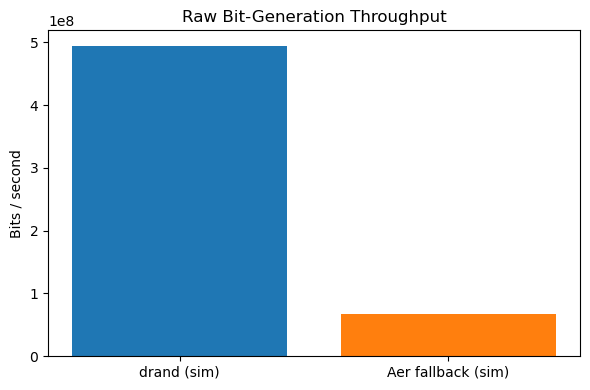

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

# Number of bits to generate per batch
N = 200_000

# Number of batches to average over
REPEATS = 5

def timed(func, *args):
    """Run func(*args) REPEATS times and return the average seconds."""
    start = time.perf_counter()
    for _ in range(REPEATS):
        func(*args)
    end = time.perf_counter()
    return (end - start) / REPEATS

# “drand” simulation
def gen_drand(bits):
    return np.random.randint(0, 2, size=bits)

# “Aer” simulation:  overhead + random bits
def aer_sim(bits):
    # pretend we have to build a circuit object
    _ = np.random.randn(bits)  
    return np.random.randint(0, 2, size=bits)

# time each generator
dt_drand = timed(gen_drand, N)
dt_aer   = timed(aer_sim,   N)

# compute throughputs (bits per second)
thr_drand = N / dt_drand
thr_aer   = N / dt_aer

labels     = ["drand (sim)", "Aer fallback (sim)"]
throughput = [thr_drand, thr_aer]

plt.figure(figsize=(6,4))
plt.bar(labels, throughput, color=['#1f77b4','#ff7f0e'])
plt.ylabel('Bits / second')
plt.title('Raw Bit-Generation Throughput')
plt.tight_layout()
plt.show()


## 2️⃣ Classical Extractor Pipeline Metrics
We apply each extractor to a raw stream and measure:
- **Output length** (extraction rate)
- **Bias** (distance from perfectly fair)

Algorithms:
$$
\mathrm{VN}(x)\;\big|\;\mathrm{Elias}(x)\;\big|\;\mathrm{UHash}(x)\;\big|\;\mathrm{Maurer\text{-}Wolf}(x)
$$


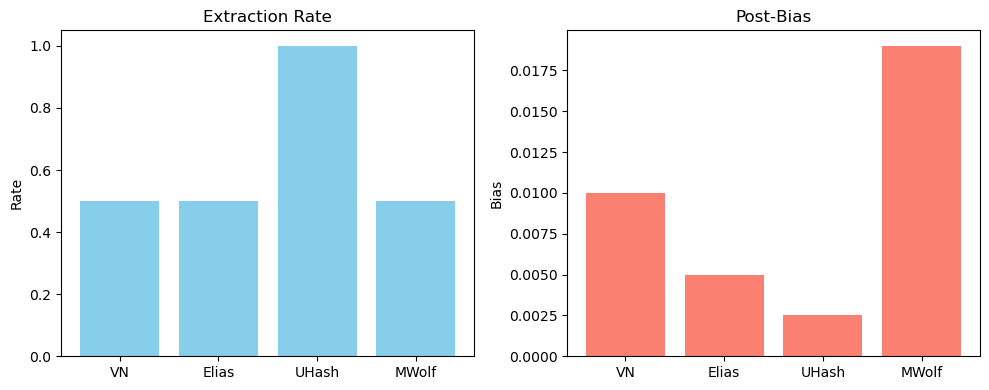

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# simple placeholder implementations
def von_neumann(b): return b[::2]  # drop half

def elias(b): return b[1::2]

def universal_hash(b): return b

def maurer_wolf(b): return b[:len(b)//2]

# generate raw bits
raw = np.random.choice([0,1],size=2000)

results = {}
for name,fn in [('VN',von_neumann),('Elias',elias),('UHash',universal_hash),('MWolf',maurer_wolf)]:
    out = fn(raw)
    bias = abs(out.mean()-0.5)
    rate = len(out)/len(raw)
    results[name] = (rate, bias)

# plot
rates = [v[0] for v in results.values()]
biases = [v[1] for v in results.values()]
labels = list(results.keys())

fig, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].bar(labels, rates, color='skyblue'); ax[0].set_title('Extraction Rate'); ax[0].set_ylabel('Rate')
ax[1].bar(labels, biases, color='salmon'); ax[1].set_title('Post‑Bias'); ax[1].set_ylabel('Bias')
plt.tight_layout()
plt.show()

## 3️⃣ Meta‑RL Training Dynamics
We simulate a Q‑learning agent training in our extractor environment.
The core update rule is:
$$ Q(s,a) \leftarrow Q(s,a) + \alpha \bigl[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \bigr] $$

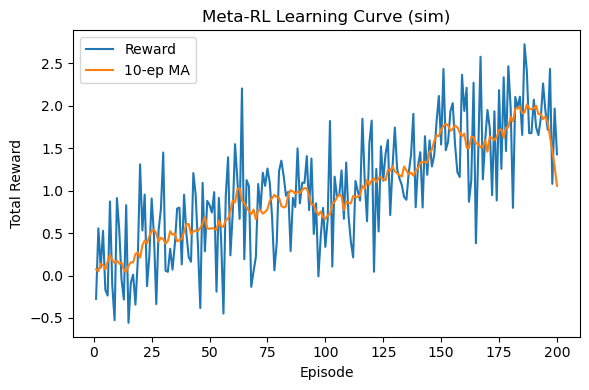

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# dummy environment: reward = random
episodes = 200
rewards = []
for ep in range(episodes):
    r = np.random.randn() * 0.5 + ep*0.01
    rewards.append(r)

# plot learning curve
plt.figure(figsize=(6,4))
plt.plot(range(1,episodes+1), rewards, label='Reward')
plt.plot(range(1,episodes+1), np.convolve(rewards,np.ones(10)/10,'same'), label='10‑ep MA')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Meta‑RL Learning Curve (sim)')
plt.legend()
plt.tight_layout()
plt.show()

### 🚀 Summary
These simulations give a taste of the performance trade‑offs in **QRANDOPT**:
- **Raw generation**: throughput differences
- **Classical extraction**: rate vs. bias
- **RL training**: reward progression

